# Лабораторна робота 4

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

### Варіант 2: Керування пранням

## Antecedent and Consequent

In [23]:
dirt = ctrl.Antecedent(np.arange(0, 101, 1), 'dirt')
load = ctrl.Antecedent(np.arange(0, 11, 1), 'load')
water = ctrl.Antecedent(np.arange(0, 101, 1), 'water')
fabric = ctrl.Antecedent(np.arange(0, 11, 1), 'fabric')

In [24]:
time = ctrl.Consequent(np.arange(0, 121, 1), 'time')

## Membership functions

In [25]:
dirt['low'] = fuzz.trimf(dirt.universe, [0, 0, 40])
dirt['medium'] = fuzz.trimf(dirt.universe, [20, 50, 80])
dirt['high'] = fuzz.trimf(dirt.universe, [60, 100, 100])

load['small'] = fuzz.trimf(load.universe, [0, 0, 4])
load['medium'] = fuzz.trimf(load.universe, [2, 5, 8])
load['large'] = fuzz.trimf(load.universe, [6, 10, 10])

water['soft'] = fuzz.trimf(water.universe, [0, 0, 40])
water['medium'] = fuzz.trimf(water.universe, [30, 50, 70])
water['hard'] = fuzz.trimf(water.universe, [60, 100, 100])

fabric['delicate'] = fuzz.trimf(fabric.universe, [0, 0, 5])
fabric['normal'] = fuzz.trimf(fabric.universe, [0, 5, 10])
fabric['heavy'] = fuzz.trimf(fabric.universe, [5, 10, 10])

time['short'] = fuzz.trimf(time.universe, [0, 0, 40])
time['normal'] = fuzz.trimf(time.universe, [30, 60, 90])
time['long'] = fuzz.trimf(time.universe, [80, 120, 120])

## Rules

In [26]:
rule1 = ctrl.Rule(dirt['low'] & load['small'], time['short'])

rule2 = ctrl.Rule(dirt['medium'] & load['medium'], time['normal'])

rule3 = ctrl.Rule(dirt['high'] | load['large'], time['long'])

rule4 = ctrl.Rule(water['hard'] & dirt['medium'], time['long'])

rule5 = ctrl.Rule(water['soft'] & dirt['low'], time['short'])

rule6 = ctrl.Rule(load['small'] & dirt['medium'], time['normal'])

rule7 = ctrl.Rule(water['hard'] & load['large'], time['long'])

rule8 = ctrl.Rule(fabric['delicate'], time['short'])

rule9 = ctrl.Rule(fabric['heavy'], time['long'])


## Нечітка сисиема керування 

In [27]:
washing_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9 ])

washing = ctrl.ControlSystemSimulation(washing_ctrl)

## Результат

Експеримент 1

Бруд: 20, Білизна: 3, Вода: 30, Тканина: 2
Час прання: 14.86 хв


c:\Users\BOS\AppData\Local\Programs\Python\Python311\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:122: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 640x480 with 0 Axes>

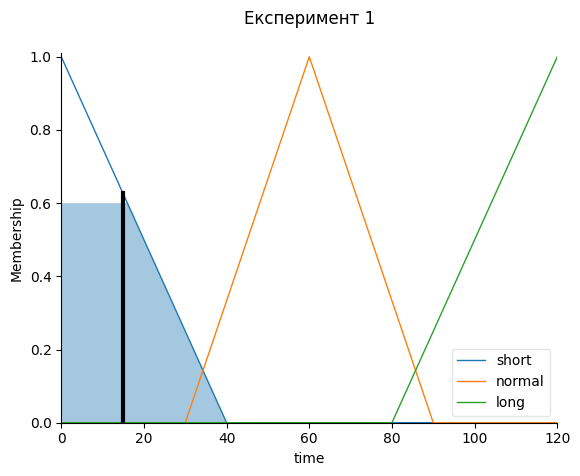

Експеримент 2

Бруд: 50, Білизна: 5, Вода: 50, Тканина: 5
Час прання: 60.00 хв


<Figure size 640x480 with 0 Axes>

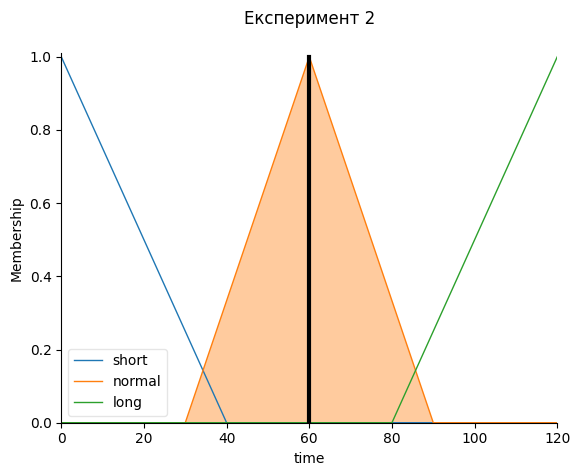

Експеримент 3

Бруд: 80, Білизна: 8, Вода: 90, Тканина: 9
Час прання: 106.22 хв


<Figure size 640x480 with 0 Axes>

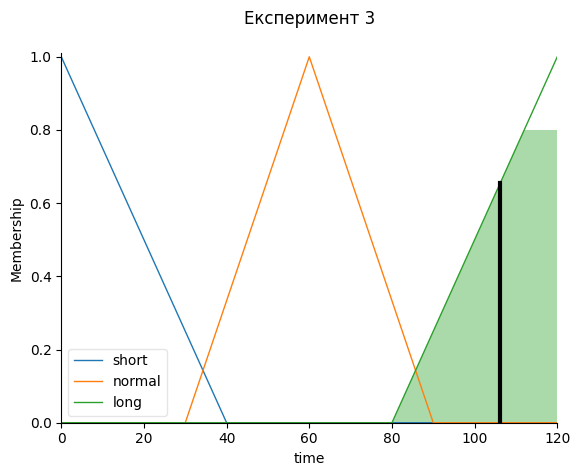

Експеримент 4

Бруд: 10, Білизна: 2, Вода: 20, Тканина: 1
Час прання: 13.78 хв


<Figure size 640x480 with 0 Axes>

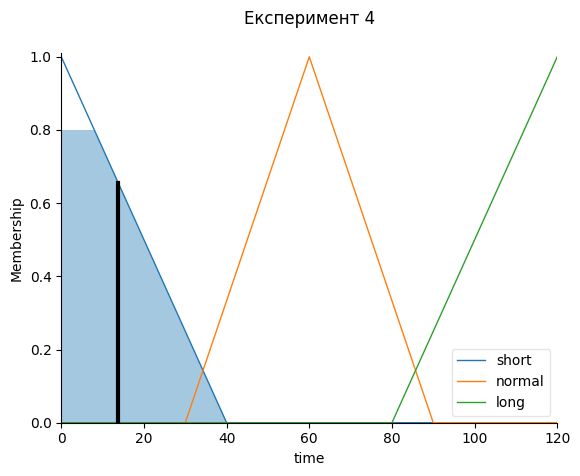

Експеримент 5

Бруд: 60, Білизна: 6, Вода: 70, Тканина: 6
Час прання: 70.17 хв


<Figure size 640x480 with 0 Axes>

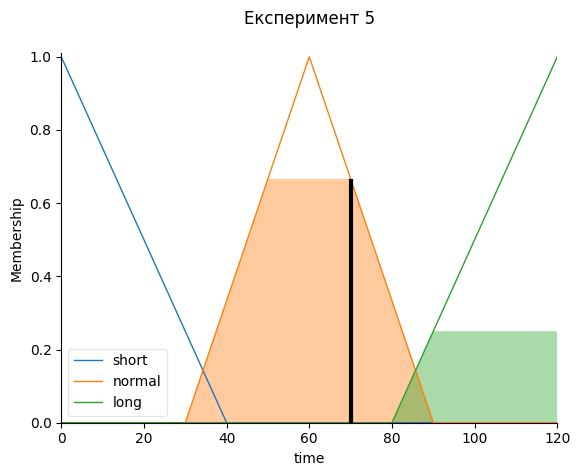

Експеримент 6

Бруд: 90, Білизна: 9, Вода: 100, Тканина: 10
Час прання: 106.67 хв


<Figure size 640x480 with 0 Axes>

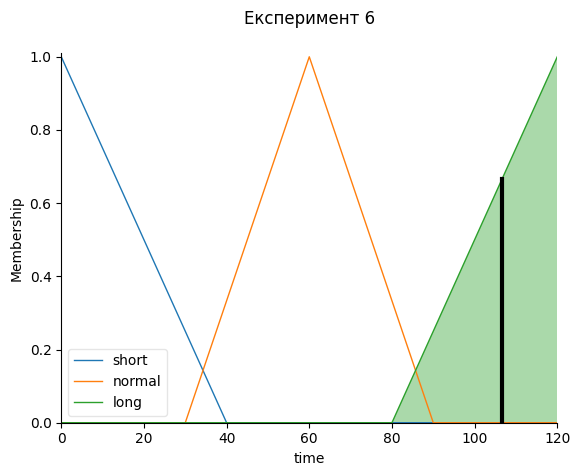

In [28]:
tests = [
    (20, 3, 30, 2),
    (50, 5, 50, 5),
    (80, 8, 90, 9),
    (10, 2, 20, 1),   
    (60, 6, 70, 6),
    (90, 9, 100, 10),
]

results = []

for i, (d, l, w, f) in enumerate(tests, start=1):
    
    print(f"Експеримент {i}")

    washing.input['dirt'] = d
    washing.input['load'] = l
    washing.input['water'] = w  
    washing.input['fabric'] = f

    washing.compute()
    time_result = washing.output['time']

    results.append([d, l, w, f, time_result])
    
    print(f"\nБруд: {d}, Білизна: {l}, Вода: {w}, Тканина: {f}")
    print(f"Час прання: {washing.output['time']:.2f} хв")

    plt.figure()
    time.view(sim=washing)
    plt.title( f"Експеримент {i}\n")
    plt.show()

In [29]:
df = pd.DataFrame(results, columns=[
    "Dirt", "Load", "Water", "Fabric", "Time (хв)"
])

print(df)

   Dirt  Load  Water  Fabric   Time (хв)
0    20     3     30       2   14.857143
1    50     5     50       5   60.000000
2    80     8     90       9  106.222222
3    10     2     20       1   13.777778
4    60     6     70       6   70.169268
5    90     9    100      10  106.666667
